In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Cargar el dataset Spambase (57 columnas de características + 1 de etiqueta)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/spambase/spambase.data"
df = pd.read_csv(url, header=None)

# La última columna (57) es la etiqueta: 1 = Spam, 0 = No Spam (Ham)
print(f"Dataset cargado con {df.shape[0]} filas y {df.shape[1]} columnas.")

Dataset cargado con 4601 filas y 58 columnas.


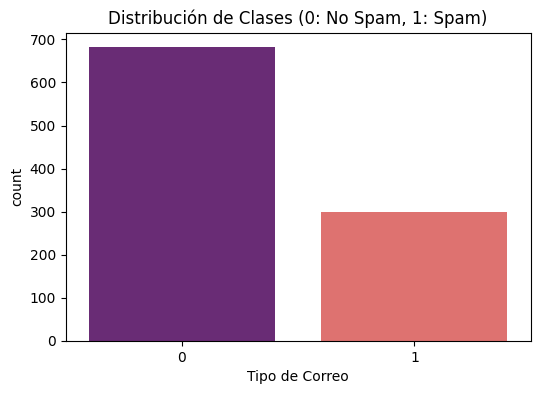

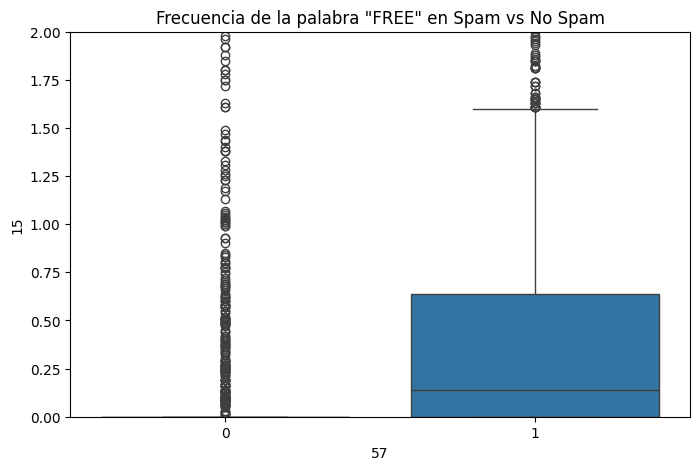

In [6]:
# Gráfico 1: ¿Cuántos correos son Spam vs No Spam?
plt.figure(figsize=(6,4))
sns.countplot(x=df[57], hue=df[57], data=df, palette='magma', legend=False)
plt.title('Distribución de Clases (0: No Spam, 1: Spam)')
plt.xlabel('Tipo de Correo')
plt.show()

# Gráfico 2: Correlación de frecuencia de palabras (Columna 15 suele ser 'free')
# Veremos cómo se distribuye la palabra "free" según si es spam o no
plt.figure(figsize=(8,5))
sns.boxplot(x=57, y=15, data=df)
plt.title('Frecuencia de la palabra "FREE" en Spam vs No Spam')
plt.ylim(0, 2) # Limitamos para ver mejor la caja
plt.show()

In [4]:
# Separar características (X) de la etiqueta (y)
X = df.drop(57, axis=1)
y = df[57]

# Dividir: 80% entrenamiento, 20% prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Crear y entrenar el modelo de Regresión Logística (Aprendizaje Supervisado)
modelo_spam = LogisticRegression(max_iter=5000) # Más iteraciones para que converja bien
modelo_spam.fit(X_train, y_train)

print("¡Modelo entrenado con éxito!")

¡Modelo entrenado con éxito!


Precisión del modelo: 92.29%


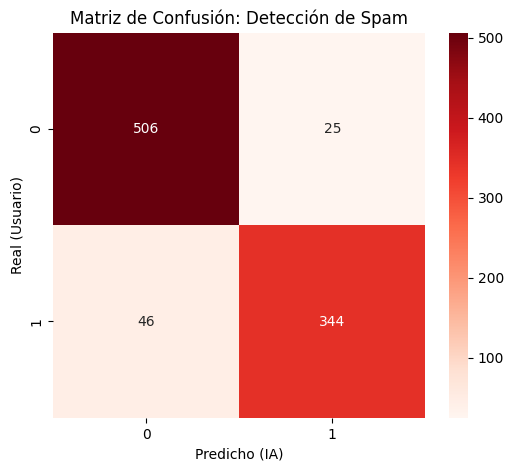

In [5]:
# Realizar predicciones
y_pred = modelo_spam.predict(X_test)

# Mostrar Precisión
print(f"Precisión del modelo: {accuracy_score(y_test, y_pred) * 100:.2f}%")

# Gráfico de Matriz de Confusión
plt.figure(figsize=(6,5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.title('Matriz de Confusión: Detección de Spam')
plt.xlabel('Predicho (IA)')
plt.ylabel('Real (Usuario)')
plt.show()